# 05 · Final model evaluation (Phase 9)

Final model (selected in Phase 8): **L2 logistic regression without pressure** — inputs fuel, O₂, CO₂, He, initial
droplet diameter and a fuel × diameter term.

Evidence below uses its **out-of-fold predictions** (each of the 252 tests predicted by models that never saw it,
5 CV repeats grouped by atmosphere), produced by `scripts/finalize_model.py` → `reports/phase9/`. All values are
**model predictions**, compared against the observed NASA outcomes.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import display
from flameguard import eda, plots
from flameguard.prediction import FinalModel

eda.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
R = ROOT / "reports" / "phase9"
fm = FinalModel.load()
oof = pd.read_csv(ROOT / "reports" / "phase8" / "final_oof_predictions.csv")
oof = oof[oof["model"] == "logreg_np"]
avg = oof.groupby("test_id").agg(y=("y_true", "first"), p=("p_sustained", "mean")).reset_index()
print(fm.metadata["model"])
print("trained on", fm.metadata["training_tests"], "tests;", fm.metadata["training_sustained"], "sustained")

L2 logistic regression (C=1), fuel x droplet-size interaction, no pressure (decision D-001)
trained on 252 tests; 80 sustained


## 1. Calibration — can the Fire Risk Score be read as a probability?

,repeat,calibration_slope,calibration_intercept,mean_predicted,observed_rate,brier
0,0,0.895,0.007,0.309,0.317,0.111
1,1,0.986,0.014,0.315,0.317,0.104
2,2,1.015,0.046,0.314,0.317,0.102
3,3,1.002,0.015,0.316,0.317,0.103
4,4,0.925,-0.053,0.318,0.317,0.106


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


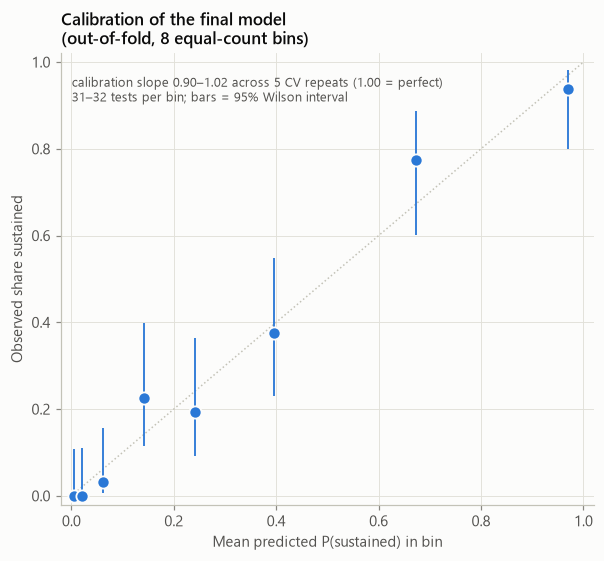

In [2]:
cal = pd.read_csv(R / "calibration_per_repeat.csv")
rel = pd.read_csv(R / "reliability.csv")
display(cal.round(3))
fig = plots.plot_reliability(rel, cal)
_ = eda.save(fig, "12_calibration")

**Read-out.** Mean predicted 0.31 vs observed 0.32 in every repeat; calibration slopes 0.90–1.02 (1 = perfect,
< 1 = slightly over-confident) and intercepts near 0. The binned points sit on the diagonal within their 95%
intervals. **No recalibration is applied** — with 252 tests a recalibration layer would add variance for no
measurable gain.

## 2. Fire Risk bands

alert threshold: Fire Risk 18.4  (largest score with out-of-fold recall >= 0.90)


,band,tests,sustained,mean_predicted,observed_sustained_rate,ci_low,ci_high
0,LOW,125,8,0.056,0.064,0.033,0.121
1,ELEVATED,65,18,0.321,0.277,0.183,0.396
2,HIGH,62,54,0.829,0.871,0.766,0.933


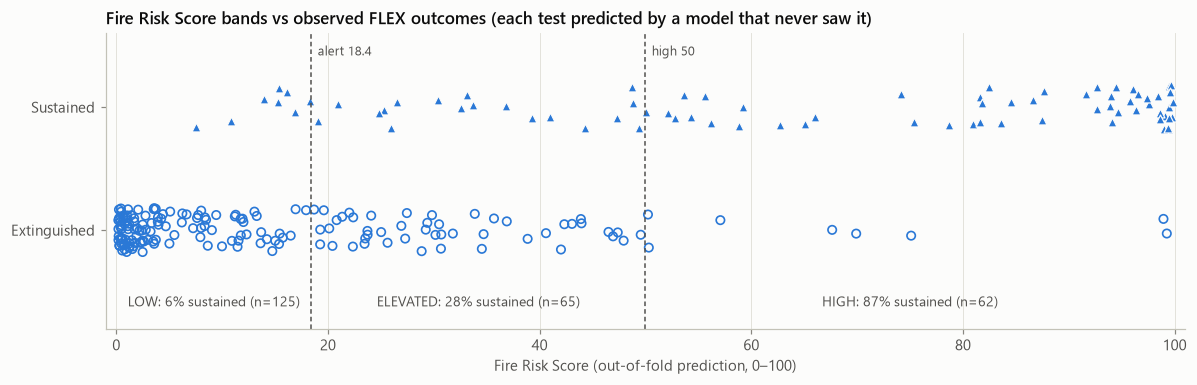

In [3]:
bands = pd.read_csv(R / "risk_bands.csv")
print(f"alert threshold: Fire Risk {100 * fm.bands.alert_threshold:.1f}  (largest score with out-of-fold recall >= 0.90)")
display(bands.round(3))
fig = plots.plot_risk_bands(avg, fm.bands)
_ = eda.save(fig, "13_risk_bands")

**Read-out.** The bands separate outcomes clearly: about 1 in 16 LOW tests, 1 in 4 ELEVATED tests and 7 in 8
HIGH tests kept burning. The LOW band is **not** "safe" — 8 of its 125 tests sustained combustion; that is the price
of the 90% recall target. The dashboard reports each band with these observed rates.

## 3. Uncertainty — 95% group-bootstrap intervals (2000 resamples of atmosphere groups)

In [4]:
pd.read_csv(R / "metrics_bootstrap.csv", index_col=0).round(3)

,estimate,ci_low,ci_high,boot_draws
roc_auc,0.918,0.870,0.964,2000
pr_auc,0.847,0.731,0.939,2000
brier,0.104,0.068,0.135,2000
log_loss,0.338,0.228,0.437,2000
recall,0.900,0.812,0.977,2000
precision,0.567,0.440,0.704,2000
false_negative_rate,0.100,0.023,0.188,2000
false_positive_rate,0.320,0.199,0.440,2000


Intervals are wide (e.g. precision 0.44–0.70) because there are only 44 atmosphere groups. Recall here uses the
single deployed threshold, chosen on these same predictions, so it is slightly optimistic; the nested estimate from
Phase 8 (threshold picked inside each training fold) is recall 0.900 ± 0.089, precision 0.625 ± 0.122.

## 4. Where the model is weaker

In [5]:
pd.read_csv(R / "subgroups.csv").round(3)

,subgroup,tests,sustained,roc_auc,brier,mean_predicted,observed_rate,recall,missed_fires,false_alarms
0,fuel=Heptane,106,50,0.932,0.108,0.461,0.472,0.940,3,28
1,fuel=Methanol,146,30,0.902,0.101,0.208,0.205,0.833,5,27
2,diluent=CO2,111,31,0.903,0.108,0.290,0.279,0.903,3,29
3,diluent=He,47,9,0.906,0.098,0.184,0.191,0.889,1,8
4,diluent=N2,94,40,0.928,0.102,0.408,0.426,0.900,4,18


In [6]:
pd.read_csv(R / "consistently_missed_fires.csv").round(3)

,test_id,flex_identifier,fuel,diluent,x_o2,x_co2,x_he,d0_mm,outcome_raw,p,missed_in_repeats,qc_flags
0,151,C03M101,Methanol,CO2,0.18,0.15,0.00,3.86,Completion,0.075,5,NaN
1,111,C10M303,Methanol,CO2,0.21,0.30,0.00,3.37,Completion,0.109,5,d_ext_without_extinction
2,112,C10M401,Methanol,CO2,0.21,0.30,0.00,3.99,Completion,0.140,5,d_ext_without_extinction
3,254,H11M102,Methanol,He,0.23,0.00,0.25,2.61,Disruption,0.153,3,NaN
4,205,N01H102,Heptane,N2,0.21,0.00,0.00,3.58,Disruption,0.154,4,NaN
5,204,N01H101,Heptane,N2,0.21,0.00,0.00,3.56,Disruption,0.161,4,NaN
6,56,194F001,Heptane,N2,0.20,0.00,0.00,3.56,Completion,0.168,5,d_ext_without_extinction
7,1,20CAL08,Methanol,N2,0.21,0.00,0.00,1.69,Disruption,0.183,4,d_ext_without_extinction
8,168,C15M101,Methanol,CO2,0.21,0.15,0.00,3.03,Disruption,0.191,3,d_ext_without_extinction


**Read-out.**
- Recall is lower for **methanol (0.83)** than heptane (0.94); per-suppressant performance is similar
  (ROC-AUC 0.90–0.93).
- Nine sustained tests are missed in at least 3 of 5 repeats; six are methanol. Four are missed in all 5 repeats:
  three large methanol droplets (3.4–4.0 mm) that **burned to completion** in CO₂-diluted atmospheres at O₂
  0.18–0.21, and one 3.6 mm heptane droplet that burned to completion at O₂ 0.20 — conditions where most
  neighbouring tests extinguished. The model has no input that separates them; this
  is reported as a limitation, not tuned away.

## 5. The deployable model

In [7]:
print(json.dumps({k: fm.metadata[k] for k in ["features", "standardised_coefficients", "scope", "label"]}, indent=1))

{
 "features": [
  "is_heptane",
  "x_o2",
  "x_co2",
  "x_he",
  "d0_mm",
  "heptane_x_d0"
 ],
 "standardised_coefficients": {
  "is_heptane": 0.5779,
  "x_o2": 2.2851,
  "x_co2": -0.5441,
  "x_he": -0.6182,
  "d0_mm": 0.3572,
  "heptane_x_d0": -1.5061
 },
 "scope": "Methanol or n-heptane droplets, quiescent microgravity (ISS FLEX), 0.7-1 atm, within the tested O2 / CO2 / He / droplet-size ranges",
 "label": "Research prototype trained on NASA PSI-69 (FLEX), DOI 10.60555/mbq8-0451. Not a certified spacecraft fire-safety system."
}


### Applicability domain — the model refuses to pretend
Each prediction carries two checks: per-fuel input ranges, and distance to the nearest tested atmosphere
(standardised O₂/CO₂/He/diameter; limit = 95th percentile of the gap between distinct tested atmospheres).

In [8]:
cases = pd.DataFrame([
    ("Methanol, O2 0.21, 3 mm", "Methanol", 0.21, 0.0, 0.0, 3.0),
    ("Heptane, O2 0.21, 3 mm", "Heptane", 0.21, 0.0, 0.0, 3.0),
    ("Heptane, O2 0.21, 4.5 mm", "Heptane", 0.21, 0.0, 0.0, 4.5),
    ("Methanol, O2 0.14 + He 0.40 (tested)", "Methanol", 0.14, 0.0, 0.40, 3.0),
    ("Methanol, O2 0.25 + CO2 0.45 (never tested together)", "Methanol", 0.25, 0.45, 0.0, 3.0),
    ("Heptane, O2 0.40 (outside range)", "Heptane", 0.40, 0.0, 0.0, 3.0),
], columns=["case", "fuel", "x_o2", "x_co2", "x_he", "d0_mm"])
res = fm.predict(cases.drop(columns="case"))
pd.concat([cases[["case"]], res[["fire_risk", "risk_band", "in_tested_range", "supported_by_data"]]], axis=1)

,case,fire_risk,risk_band,in_tested_range,supported_by_data
0,"Methanol, O2 0.21, 3 mm",28.7,ELEVATED,True,True
1,"Heptane, O2 0.21, 3 mm",56.4,HIGH,True,True
2,"Heptane, O2 0.21, 4.5 mm",2.9,LOW,True,False
3,"Methanol, O2 0.14 + He 0.40 (tested)",0.2,LOW,True,True
4,"Methanol, O2 0.25 + CO2 0.45 (never tested tog...",32.0,ELEVATED,True,False
5,"Heptane, O2 0.40 (outside range)",100.0,HIGH,False,False


The 4.5 mm heptane case shows why the check matters: its LOW score comes from extrapolating the fuel × size
term to a droplet size that was only tested for heptane at low O₂, and it is flagged as unsupported. The dashboard
will show such predictions greyed out with the warning text, never as a clean number.

## Summary
| | |
|---|---|
| Calibration | slope 0.90–1.02, mean predicted 0.31 vs observed 0.32 — no recalibration needed |
| Alert threshold | Fire Risk 18.4 (≥ 90% of sustained tests flagged out-of-fold) |
| Bands | LOW 6% / ELEVATED 28% / HIGH 87% observed sustained |
| Honest performance (nested CV) | ROC-AUC 0.925 ± 0.045, recall 0.900 ± 0.089, precision 0.625 ± 0.122 |
| Main weakness | methanol recall 0.83; large methanol droplets burning to completion in CO₂ near O₂ 0.21 |

Documented in `docs/model_card.md`. Next (Phase 10): SHAP explanations for the final model.